# Expansion points and energy: interpreting CLN correctly

This continues [What is CLN?](00_what_is_cln.ipynb). It demonstrates how elements and errors change when the expansion point changes for the same circular wire. FEM and Wolfram are not required.

## 1. An expansion point does not change the physical system

The exact wire impedance $Z(s)$ remains the same. A finite circuit expanded in $q=s-s_0$ and truncated depends on $s_0$. Different element values reflect the representation and approximation, not a changed conductor.

Here $s_0$ is a **positive real Laplace point**. Do not reinterpret “expansion at frequency $f_0$” as $s_0=j2\pi f_0$. The following dimensionless variables are $z=\tau s$, $z_0=\tau s_0$, and $q=z-z_0$.

The code extracts a seven-element Type2 continued fraction from Taylor coefficients of the Bessel solution using the Euclidean algorithm. It is an **analytic reference** independent of field-energy extraction, not FEM-based CLN generation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
mp.mp.dps=80
plt.rcParams.update({"figure.dpi":110,"font.size":11})
def F(z):
    k=mp.sqrt(z)
    return k*mp.besseli(0,k)/(2*mp.besseli(1,k))
def reciprocal(c):
    out=[1/c[0]]
    for n in range(1,len(c)):
        out.append(-mp.fsum(c[i]*out[n-i] for i in range(1,n+1))/c[0])
    return out
def extract(z0,count=7):
    seq=mp.taylor(F,mp.mpf(z0),count+2)
    result=[]
    for n in range(count):
        result.append(seq[0] if n%2==0 else 1/seq[0])
        seq=seq[1:]
        if n<count-1: seq=reciprocal(seq)
    assert all(v>0 for v in result)
    return result
models={z0:extract(z0) for z0 in (1,10,80)}
def ladder(c,q):
    if q==0:return c[0]
    value=c[-1]
    for i in range(len(c)-2,-1,-1):
        value=c[i]+value if i%2==0 else q*c[i]*value/(q*c[i]+value)
    return value
for z0,c in models.items():
    assert abs(ladder(c,mp.mpf(0))/F(z0)-1)<mp.mpf('1e-65')
    print('z0=',z0,'[R0,L1,R2,L3,R4,L5,R6]=',[float(x) for x in c])
    # A seven-element truncation should have order-seven contact.
    errors=[abs(ladder(c,mp.mpf(z0)*h)/F(mp.mpf(z0)*(1+h))-1) for h in (mp.mpf('.001'),mp.mpf('.0001'))]
    order=mp.log10(errors[0]/errors[1])
    assert abs(order-7)<mp.mpf('.03')
    print('measured local order:',float(order))


z0= 1 [R0,L1,R2,L3,R4,L5,R6]= [1.1200968619350449, 0.1154798818183099, 3.0666053062273364, 0.06196250572931506, 5.0213805346565925, 0.04156588522682069, 7.010558107106398]
measured local order: 6.999890627666975
z0= 10 [R0,L1,R2,L3,R4,L5,R6]= [1.9251628969197876, 0.07189107172431987, 3.856377388147359, 0.0558769334988995, 5.274075000305616, 0.040492918748154846, 7.120302521764528]
measured local order: 6.999377596363988
z0= 80 [R0,L1,R2,L3,R4,L5,R6]= [4.745877395632916, 0.027781564265668093, 9.016668512330396, 0.027636619085364203, 9.098611014023604, 0.02717689216716186, 9.38715972604435]
measured local order: 6.998710526156177


## 2. Separate local real-axis matching from AC-band accuracy

The left plot shows errors on the positive real $z$ axis; the right shows errors on the physical AC axis $s=j\omega$. Small error near a real expansion point and adequate accuracy in the target AC band are separate checks. Introducing an expansion point is not itself evidence of high accuracy without examining the AC error.


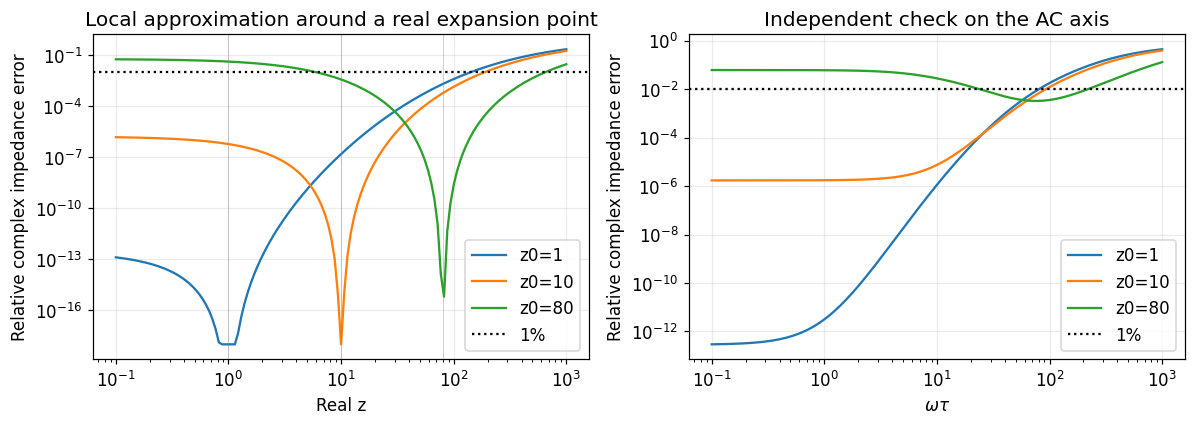

In [2]:
grid=np.logspace(-1,3,141)
fig,ax=plt.subplots(1,2,figsize=(11,4))
for z0,c in models.items():
    real_error=[float(abs(ladder(c,mp.mpf(v)-z0)/F(mp.mpf(v))-1)) for v in grid]
    ac_error=[float(abs(ladder(c,mp.mpc(0,v)-z0)/F(mp.mpc(0,v))-1)) for v in grid]
    assert np.isfinite(real_error).all() and np.isfinite(ac_error).all()
    ax[0].loglog(grid,np.maximum(real_error,1e-18),label=f'z0={z0}')
    ax[0].axvline(z0,color='gray',lw=.6,alpha=.4)
    ax[1].loglog(grid,np.maximum(ac_error,1e-18),label=f'z0={z0}')
for a in ax:
    a.axhline(.01,color='black',ls=':',label='1%');a.grid(alpha=.25);a.legend();a.set_ylabel('Relative complex impedance error')
ax[0].set(xlabel='Real z',title='Local approximation around a real expansion point')
ax[1].set(xlabel=r'$\omega\tau$',title='Independent check on the AC axis')
plt.tight_layout();plt.show()


## 2a. Plot admittance and error together: what does “N=3” count?

The original seven-element curves above are correct: independent `[3/3]` Padé of $F=Z/R_{dc}$ gives the same AC errors. But dimensionless $z_0$ is not a frequency in Hz. For a round wire, $\tau=\mu\sigma a^2$ and $z_0=2\pi f_0\tau$. Here the **new illustrative specimen** has $a=5$ mm, $\sigma=5.8\times10^7$ S/m, $\mu=\mu_0$, length 1 m, internal impedance only; $\tau=1.8221$ ms. Its three real shifts are $f_0=1,10,100$ kHz, hence $z_0=11.45,114.49,1144.89$. They are not the original $z_0=1,10,80$.

For this comparison only, **N=3 means three RL pairs**: six elements $[R_0,L_1,R_2,L_3,R_4,L_5]$ (upper row), or those pairs **plus a terminal resistor $R_6$**, seven elements (lower row). Their $Z$ approximants are respectively `[3/2]` and `[3/3]`; their reciprocal $Y$ approximants are `[2/3]` and `[3/3]`. These different terminations have different high-frequency limits. A six-element ladder ends with $qL_5$, not $L_5$. Each is independently checked against direct Padé of both $Z$ and $Y$.

The log panels show $\operatorname{Re}Y$ and $-\operatorname{Im}Y$ for the $e^{j\omega t}$ convention. A 1% component difference is only $\log_{10}(1.01)=0.00432$ decade; visually overlapping curves do not prove 1% accuracy. The adjacent panel uses **complex relative admittance error**, not separate component errors. With $\epsilon=Z_{red}/Z_{exact}-1$, $e_Z=|\epsilon|$ and $e_Y=|\epsilon|/|1+\epsilon|$; reciprocation does not generally make their relative errors equal.

Increasing a **real** shift can move an accurate AC window to higher frequencies, while worsening DC accuracy. No imaginary shift is needed to explain this qualitative behaviour. The original $z_0=1$ and 10 become similar when $\omega\tau$ dominates both shifts; that observation is not a universal upper-band limit. In this new specimen the seven-element 1% windows move from roughly 10 Hz–8.13 kHz, through 3.55–25.7 kHz, to 39.8–245 kHz. Six elements at 100 kHz narrowly miss 1% even at their best point (about 1.0012%). All boundaries below are sampled on a 2.33%-spacing grid, not root-refined thresholds.

A six-element **analytic Type1** comparison expands $H=F/z$ at the same real points and reconstructs $F_{red}=zH_{red}$. Its continued fraction is $H_{red}=1/(1/L_0+q/(R_0+q/(1/L_1+\cdots)))$, independently checked against `[2/3]` Padé of $H$. This is analytic coefficient extraction, not new field-energy extraction. A finite shifted $H$ approximation need not retain the pole at $z=0$: here $F_{red}(0)=0$, so it loses the wire's DC resistance. Its high-frequency windows must not be presented as broadband/DC accuracy. A separate **DC-preserving Padé control** uses $(F-1)/z$ and reconstructs $1+zH_{red}$; that control is not identified as a Type1 field circuit. Both sets of sampled 1% windows are printed below.

**Literature scope:** [Kuriyama et al., IEEE Transactions on Magnetics 55(6), 2019, DOI 10.1109/TMAG.2019.2900766](https://repository.kulib.kyoto-u.ac.jp/handle/2433/244835), Fig.8, uses a rectangular iron bar, four stages, and real $s_0=2\pi f_0$. This circular-wire example is not a numerical reproduction of that figure, nor of a separate N=3 Re/Im-Y figure. The geometry, material, normalization, truncation and definition of accuracy must be matched before claiming quantitative agreement. No publication curves were digitized.


tau [s]: 0.00182212373908208 Rdc [ohm]: 0.000219524059437097
Type2 6 f0 [Hz]= 1000 sampled 1% Y intervals [Hz]= [[10.0, 4897.7881936844615]]
Type2 6 f0 [Hz]= 10000 sampled 1% Y intervals [Hz]= [[7413.102413009177, 12882.495516931323]]
Type2 6 f0 [Hz]= 100000 sampled 1% Y intervals [Hz]= []
Type2 7 f0 [Hz]= 1000 sampled 1% Y intervals [Hz]= [[10.0, 8128.305161640995]]
Type2 7 f0 [Hz]= 10000 sampled 1% Y intervals [Hz]= [[3548.1338923357566, 25703.957827688646]]
Type2 7 f0 [Hz]= 100000 sampled 1% Y intervals [Hz]= [[39810.71705534969, 245470.89156850285]]
Type1 analytic H continued fraction 6 f0 [Hz]= 1000 sampled 1% Y intervals [Hz]= [[79.43282347242814, 2691.5348039269165]]
Type1 analytic H continued fraction 6 f0 [Hz]= 10000 sampled 1% Y intervals [Hz]= []
Type1 analytic H continued fraction 6 f0 [Hz]= 100000 sampled 1% Y intervals [Hz]= []
DC-preserving H Pade control H [2/3] control f0 [Hz]= 1000 sampled 1% Y intervals [Hz]= [[10.0, 7943.282347242814]]
DC-preserving H Pade control H

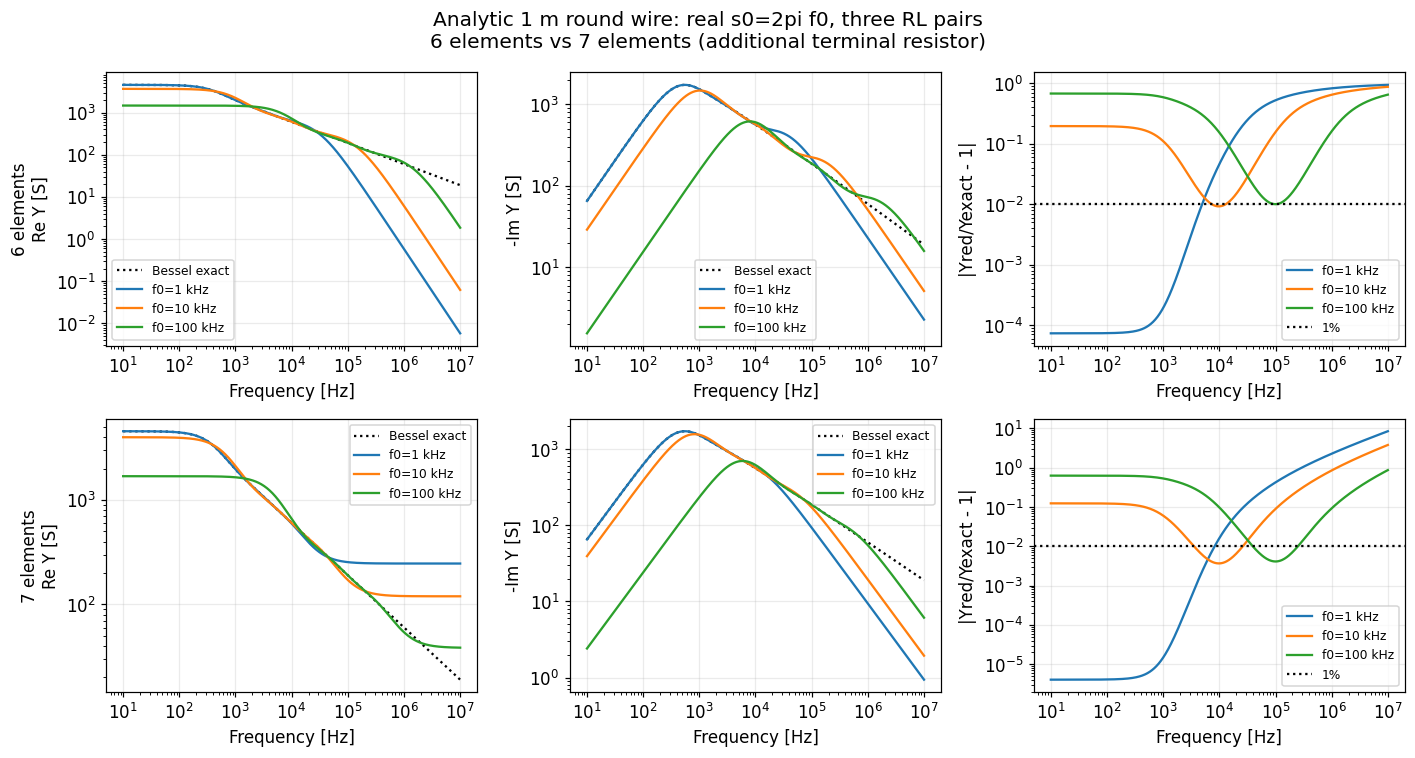

In [3]:
import sys
from pathlib import Path
study_root = Path.cwd().parent if Path.cwd().name == 'docs' else Path.cwd()
sys.path.insert(0, str(study_root / 'validation'))
from ac_axis_study import study, plot
ac_record = study()  # genuine analytic recomputation, 80-digit Taylor/Padé checks
print('tau [s]:', ac_record['tau_s'], 'Rdc [ohm]:', ac_record['rdc_ohm'])
for item in ac_record['models']:
    print(item['family'], item.get('elements', 'H [2/3] control'),
          'f0 [Hz]=', item['f0_hz'], 'sampled 1% Y intervals [Hz]=',
          item['one_percent_intervals_hz'])
plot(ac_record)
plt.show()


## 3. Positive shifted elements require careful interpretation

A Type2 inductive branch is $qL=(s-s_0)L$. In physical $s$ it is $sL-s_0L$, not simply a conventional inductor. Positive elements in the $q$ representation alone therefore do not establish passivity of the finite approximation in $s$. Poles, stability, and target-band errors require separate checks.

Type1 additionally expands $Z/s$ and includes $R/q$ branches. Type1 and Type2 are not alternative names for the same R and L values.

| Comparison | What may agree |
|---|---|
| Same Z, expansion point, Type, normalization, and truncation procedure | Continued-fraction coefficients in nondegenerate cases |
| A and T with the same Type | Correctly matched continuum fields and circuit constants; finite meshes retain errors |
| Type1 and Type2 | The target Z; identical element values are not required |
| Finite circuits at different expansion points | Compare measured accuracy in a specified band |

## 4. Which integrals define R and L?

With this repository's normalization, Type2 even stages satisfy
$$R_{2n}^{-1}=P_j(E_{2n})+s_0W_m(H_{2n}),\quad
H_{2n+1}=R_{2n}H_{2n}+H_{2n-1},\quad L_{2n+1}=W_m(H_{2n+1}).$$
For Type1, $R_{2n}^{-1}=P_j(E_{2n})$, while odd stages use $L=(P_j+s_0W_m)/s_0$. Here $W_m$ names the quadratic form $\int\mu H^2$, without the stored-energy factor $1/2$.

“Energy-based” means that **field integrals and normalization determine the meaning of each element**. It does not mean every shifted R is pure Joule loss.

## 5. What is established, and what is not?

The existing A/T boundary conditions and normalization were not changed. The derivation traces physical-field reconstruction from the unknowns and demonstrates the same circuit.

- **Type2:** circular wire, positive real shift, analytic R0/L1/R2/L3 derivation; independently reviewed.
- **Type1:** circular wire, positive real shift, analytic L-1/R0/L1/R2 derivation; separate A/T finite elements converge to the same analytic values.
- **Not proved:** arbitrary stages, general 3D mixed formulations, complex shifts, or extensions of this proof to nonlinear fields.

The following NGSolve results are stored evidence, not new solves. Use the [Type1 notebook](type1_same_circuit.ipynb) to reproduce the FEM calculations.


A max relative element error, finest mesh: 2.0957589931258624e-06
T max relative element error, finest mesh: 1.104252388195448e-06
A/T difference, finest mesh: 3.2000078477034677e-06


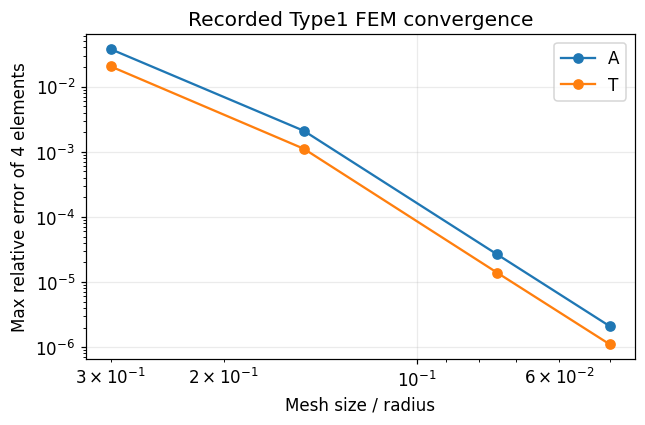

In [4]:
import json
from pathlib import Path
base=Path.cwd() if Path.cwd().name=='docs' else Path.cwd()/'docs'
record=json.loads((base/'data/type1_radia_ngsolve.json').read_text())
assert record['passed']
h=np.array([row['maxh'] for row in record['cases']])
fig,ax=plt.subplots(figsize=(6,4))
for name in ('A','T'):
    err=[max(abs(v) for v in row[name]['relative_errors']) for row in record['cases']]
    ax.loglog(h,err,'o-',label=name)
    print(name,'max relative element error, finest mesh:',err[-1])
ax.set(xlabel='Mesh size / radius',ylabel='Max relative error of 4 elements',title='Recorded Type1 FEM convergence')
ax.invert_xaxis();ax.grid(alpha=.25);ax.legend();plt.tight_layout();plt.show()
print('A/T difference, finest mesh:',record['fine_A_T_relative_difference'])


## Follow the derivation

[Type2 symbolic verification](type2_same_circuit.ipynb) → [Type1 symbolic verification and FEM reproduction](type1_same_circuit.ipynb).

The plots use public code and the analytic Bessel solution. The seven-element plots demonstrate **analytic continued-fraction extraction**; they do not extend the proof of circuit equivalence from A/T fields to seven elements.
